In [2]:
import jax
import flax
import optax
from jax import lax, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

Dataset summary:
<xarray.Dataset> Size: 3GB
Dimensions:   (sample: 10000, x: 128, y: 128)
Coordinates:
  * x         (x) float64 1kB 0.0 0.007874 0.01575 0.02362 ... 0.9843 0.9921 1.0
  * y         (y) float64 1kB 0.0 0.007874 0.01575 0.02362 ... 0.9843 0.9921 1.0
Dimensions without coordinates: sample
Data variables:
    solution  (sample, x, y) float64 1GB ...
    source    (sample, x, y) float64 1GB ...
    k         (sample) float64 80kB ...
Attributes:
    description:         2D Helmholtz Equation Dataset with Sinusoidal Superp...
    equation:            (nabla^2 + k)u = q
    n_max_terms:         5
    boundary_condition:  Homogeneous Dirichlet (u=0)

Extracted Source (q) Shape: (16384, 1)
Extracted k Value: 7.7288
Extracted Solution (u) Shape: (16384, 1)


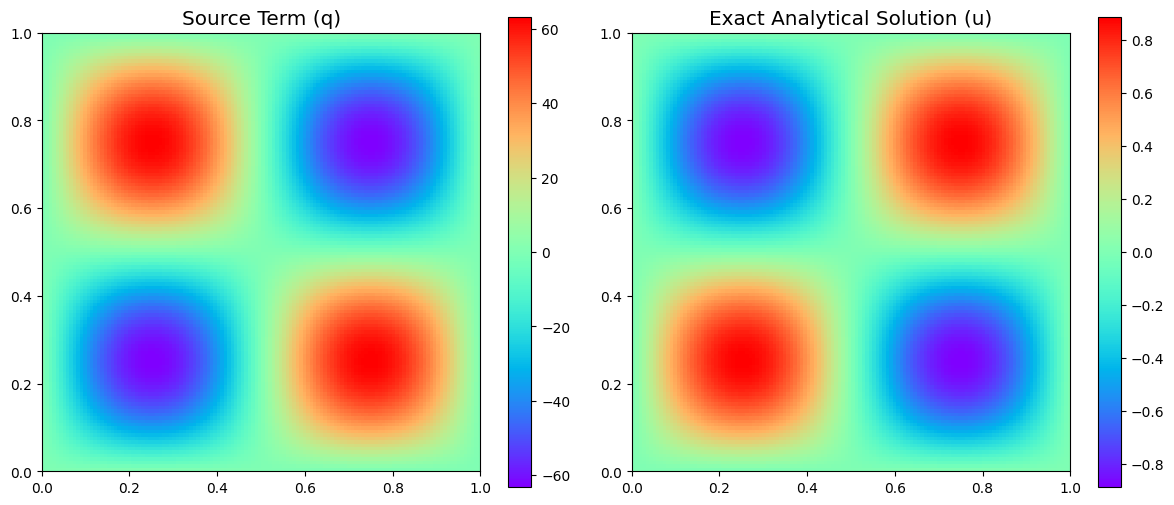

In [3]:
import xarray as xr

DATA_DIR = Path.cwd().parent.parent / "data"
FILE_PATH = DATA_DIR / "Helmholtz-Sinusoidal.nc"

ds = xr.open_dataset(FILE_PATH)
print(f"Dataset summary:\n{ds}\n")

# Extract a single sample for the solver
sample_idx = 3 

source_sample = ds['source'][sample_idx].values
solution_sample = ds['solution'][sample_idx].values
k_val = ds['k'][sample_idx].values  # <-- NEW: Extract k

# Flatten for network
q_flat = source_sample.reshape(-1, 1)
u_flat = solution_sample.reshape(-1, 1)

print(f"Extracted Source (q) Shape: {q_flat.shape}")
print(f"Extracted k Value: {k_val:.4f}")
print(f"Extracted Solution (u) Shape: {u_flat.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
domain_extent = [0.0, 1.0, 0.0, 1.0]

im1 = axes[0].imshow(source_sample.T, origin='lower', cmap='rainbow', extent=domain_extent)
fig.colorbar(im1, ax=axes[0])
axes[0].set_title('Source Term (q)', fontsize='x-large')

im2 = axes[1].imshow(solution_sample.T, origin='lower', cmap='rainbow', extent=domain_extent)
fig.colorbar(im2, ax=axes[1])
axes[1].set_title('Exact Analytical Solution (u)', fontsize='x-large')

plt.tight_layout()
plt.show()

In [4]:
class HelmholtzDataset(Dataset):
    def __init__(self, source_data, solution_data, k_data):
        self.s = source_data.reshape(source_data.shape[0], -1, 1)
        self.u = solution_data.reshape(solution_data.shape[0], -1, 1)
        self.k = k_data.reshape(-1, 1) 

    def __len__(self):
        return len(self.u)

    def __getitem__(self, idx):
        return self.s[idx], self.k[idx], self.u[idx]

ds = xr.open_dataset(FILE_PATH)
all_source = ds['source'].values
all_solution = ds['solution'].values
all_k = ds['k'].values 
ds.close()

n_train = 9640
n_val = 120
n_test = 240

train_dataset = HelmholtzDataset(
    source_data=all_source[:n_train], 
    solution_data=all_solution[:n_train], 
    k_data=all_k[:n_train]
)

val_dataset = HelmholtzDataset(
    source_data=all_source[n_train : n_train + n_val], 
    solution_data=all_solution[n_train : n_train + n_val], 
    k_data=all_k[n_train : n_train + n_val]
)

test_dataset = HelmholtzDataset(
    source_data=all_source[-n_test:], 
    solution_data=all_solution[-n_test:], 
    k_data=all_k[-n_test:]
)

batch_size_samples = 8
train_dataloader = jd.DataLoader(
    train_dataset, backend='pytorch', batch_size=batch_size_samples, 
    shuffle=True, drop_last=True, num_workers=0
)

val_dataloader = jd.DataLoader(
    val_dataset, backend='pytorch', batch_size=batch_size_samples, 
    shuffle=False, num_workers=0 
)

test_dataloader = jd.DataLoader(
    test_dataset, backend='pytorch', batch_size=batch_size_samples, 
    shuffle=False, num_workers=0 
)

print("DataLoaders ready for training loop!")

DataLoaders ready for training loop!


In [5]:
nx, ny = 128, 128

x_coords = np.linspace(0.0, 1.0, nx, dtype=np.float64)
y_coords = np.linspace(0.0, 1.0, ny, dtype=np.float64)

X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Dirichlet Boundary Condition Logic
x_l, x_u = 0.0, 1.0
y_l, y_u = 0.0, 1.0

bc_left = (x == x_l).flatten() 
bc_right = (x == x_u).flatten()
bc_bottom = (y == y_l).flatten()
bc_top = (y == y_u).flatten()

bc_all = bc_left | bc_right | bc_bottom | bc_top 

# Extract boundary coordinates (Targets are strictly 0.0)
x_bc = x[bc_all]
y_bc = y[bc_all]

# Extract interior points for PDE evaluation
interior_mask = ~bc_all
x_interior = x[interior_mask]
y_interior = y[interior_mask]

print(f"Total interior PDE points: {x_interior.shape[0]}")
print(f"Total boundary points: {x_bc.shape[0]}")

E0725 23:41:28.483941   40412 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0725 23:41:28.605805   40167 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


Total interior PDE points: 15876
Total boundary points: 508


In [6]:
epochs = 1000
M = 512 
chunk_size = 256 
hidden_layers = [256, 256, 256, 256] 
# total_features = (2 * M) + sum(hidden_layers) # 1024 for concat
total_features = hidden_layers[-1]

sigma = 1.0 
tik_reg_fixed = 1e-6 
matrix_bc_weight = 1e4
pde_loss_weight = 1
bc_loss_weight = 1e4
data_loss_weight = 0

# sigma = 3.0 
# tik_reg_fixed = 1e-4 
# matrix_bc_weight = 1e11
# pde_loss_weight = 1e-6
# bc_loss_weight = 1e4
# data_loss_weight = 0

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M))

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        raw_sigma = self.param('raw_sigma', nn.initializers.constant(3.0), (1,))
        sigma = jax.nn.softplus(raw_sigma)
          
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            
        return h 

model = FeatureExtractor(hidden_layers=hidden_layers, B_matrix_base=B_matrix_base)

key = jax.random.PRNGKey(0)
params = model.init(key, jnp.array([0.0]), jnp.array([0.0]))

In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_xx, u_yy

# VMAPs reverted
f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [8]:
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=epochs, alpha=0.1)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

def get_A_and_b(params, x_pde, y_pde, q_pde, k_val, x_bc, y_bc, total_features, chunk_size):
    A_chunks = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        f_chunk = f_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        A_pde_chunk = f_xx + f_yy + k_val * f_chunk
        f_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx)
        A_bc_chunk = f_bc_chunk * jnp.sqrt(matrix_bc_weight)
        
        A_chunk = jnp.vstack([A_pde_chunk, A_bc_chunk])
        A_chunks.append(A_chunk)
        
    A_full = jnp.hstack(A_chunks)
    b_pde = q_pde 
    b_bc = jnp.zeros_like(x_bc) * jnp.sqrt(matrix_bc_weight)
    b_full = jnp.vstack([b_pde, b_bc])
    
    return A_full, b_full

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def solve_w(params, x_pde, y_pde, q_pde, k_val, x_bc, y_bc, total_features, chunk_size):
    A, b = get_A_and_b(params, x_pde, y_pde, q_pde, k_val, x_bc, y_bc, total_features, chunk_size)
    AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
    Atb = A.T @ b
    return jax.scipy.linalg.solve(AtA, Atb, assume_a='pos')

# Base function: expects a SINGLE sample's data
def compute_all_losses(params, x_pde, y_pde, q_sample, k_sample, x_bc, y_bc, u_sample):
    w_current = solve_w(params, x_pde, y_pde, q_sample, k_sample, x_bc, y_bc, total_features, chunk_size)
    
    u_xx, u_yy = u_dir_spatial_vmap(params, x_pde, y_pde, w_current)
    laplacian_u = u_xx + u_yy
    f_interior = f_spatial_vmap(params, x_pde, y_pde)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    pde_residual = laplacian_u + k_sample * u_pred_interior - q_sample
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - 0.0) ** 2) 
    loss_data_unscaled = jnp.mean((u_pred_interior - u_sample) ** 2)
    
    loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
    loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
    loss_data_scaled = loss_data_unscaled * data_loss_weight
    
    aux_unscaled = (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)
    return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), aux_unscaled

batched_compute_all_losses = jax.vmap(
    compute_all_losses,
    in_axes=(None, None, None, 0, 0, None, None, 0)
)

def mean_compute_all_losses(params, x_batch, y_batch, q_batch, k_batch, x_bc, y_bc, u_batch):
    losses_batch, aux_batch = batched_compute_all_losses(params, x_batch, y_batch, q_batch, k_batch, x_bc, y_bc, u_batch)
    mean_losses = (jnp.mean(losses_batch[0]), jnp.mean(losses_batch[1]), jnp.mean(losses_batch[2]))
    mean_aux = (jnp.mean(aux_batch[0]), jnp.mean(aux_batch[1]), jnp.mean(aux_batch[2]))
    return mean_losses, mean_aux

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, q_batch, k_batch, x_bc, y_bc, u_batch, total_features, chunk_size):
    loss_tuple, vjp_fn, aux_unscaled = jax.vjp(
        lambda p: mean_compute_all_losses(p, x_batch, y_batch, q_batch, k_batch, x_bc, y_bc, u_batch),
        params,
        has_aux=True
    )
    
    l_pde_scaled, l_bc_scaled, l_data_scaled = loss_tuple
    
    pde_grads = vjp_fn((1.0, 0.0, 0.0))[0]
    bc_grads = vjp_fn((0.0, 1.0, 0.0))[0]
    data_grads = vjp_fn((0.0, 0.0, 1.0))[0]
    total_grads = vjp_fn((1.0, 1.0, 1.0))[0] 
    
    total_loss = l_pde_scaled + l_bc_scaled + l_data_scaled
    
    updates, opt_state = optimizer.update(total_grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    grad_norms = (
        optax.global_norm(total_grads),
        optax.global_norm(pde_grads),
        optax.global_norm(bc_grads),
        optax.global_norm(data_grads)
    )
    
    return new_params, opt_state, total_loss, aux_unscaled, grad_norms

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def eval_step(params, x_pde, y_pde, q_batch, k_batch, x_bc, y_bc, u_batch, total_features, chunk_size):
    _, aux_batch = batched_compute_all_losses(params, x_pde, y_pde, q_batch, k_batch, x_bc, y_bc, u_batch)
    return jnp.mean(aux_batch[2]) # Return unscaled Data MSE for tracking

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_interior_points = x_interior.shape[0]
spatial_batch_size = 5000

history_total = []
history_pde = []
history_bc = []
history_data = []

def evaluate_val_dataset(params):
    total_mse = 0.0
    total_samples = 0
    for q_b, k_b, u_b in val_dataloader:
        # Full interior grid evaluation
        batch_mse = eval_step(params, x_interior, y_interior, q_b, k_b, x_bc, y_bc, u_b, total_features, chunk_size)
        current_bs = q_b.shape[0]
        total_mse += float(batch_mse) * current_bs
        total_samples += current_bs
    return total_mse / total_samples

for epoch in range(epochs):
    epoch_l_tot, epoch_l_pde, epoch_l_bc, epoch_l_data = 0.0, 0.0, 0.0, 0.0
    num_batches = 0
    
    for q_batch, k_batch, u_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        rng, shuffle_key = jax.random.split(rng)
        
        # Spatial Subsampling (Memory safety)
        batch_idx = jax.random.choice(shuffle_key, total_interior_points, shape=(spatial_batch_size,), replace=False)
        
        x_chunk = x_interior[batch_idx]
        y_chunk = y_interior[batch_idx]
        
        # Slice the loaded batches to match the sampled spatial points
        q_chunk = q_batch[:, interior_mask][:, batch_idx, :]
        u_chunk = u_batch[:, interior_mask][:, batch_idx, :]
        
        params, opt_state, loss, (l_pde, l_bc, l_data), norms = update_network(
            params, opt_state, x_chunk, y_chunk, q_chunk, k_batch, x_bc, y_bc, u_chunk, total_features, chunk_size
        )
        
        epoch_l_tot += float(loss)
        epoch_l_pde += float(l_pde)
        epoch_l_bc += float(l_bc)
        epoch_l_data += float(l_data)
        num_batches += 1
        
    history_total.append(epoch_l_tot / num_batches)
    history_pde.append(epoch_l_pde / num_batches)
    history_bc.append(epoch_l_bc / num_batches)
    history_data.append(epoch_l_data / num_batches)
    
    if (epoch + 1) % 10 == 0:
        g_tot, g_pde, g_bc, g_data = norms
        val_mse = evaluate_val_dataset(params)
        print(f"Epoch {epoch+1:<3} | Tot: {history_total[-1]:.3e} | PDE: {history_pde[-1]:.3e} | BC: {history_bc[-1]:.3e} | Data: {history_data[-1]:.3e}")
        print(f"            ├─ Grad Norms => Tot: {g_tot:.3e} | PDE: {g_pde:.3e} | BC: {g_bc:.3e} | Data: {g_data:.3e}")
        print(f"            └─ Validation MSE: {val_mse:.4e}")

Epoch 1/1000:   0%|          | 0/1205 [00:00<?, ?it/s]

E0725 23:41:36.776994   40422 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Plot 1: Overall Total Loss
axes[0].plot(history_total, color='black', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_title('Overall Total Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss (Log Scale)', fontsize=12)
axes[0].grid(True, which="both", ls="-", alpha=0.3)

# Plot 2: PDE Loss
axes[1].plot(history_pde, color='blue', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_title('PDE Loss', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].grid(True, which="both", ls="-", alpha=0.3)

# Plot 3: BC Loss
axes[2].plot(history_bc, color='green', linewidth=2)
axes[2].set_yscale('log')
axes[2].set_title('Boundary Condition (BC) Loss', fontsize=14)
axes[2].set_xlabel('Epochs', fontsize=12)
axes[2].grid(True, which="both", ls="-", alpha=0.3)

# Plot 4: Data MSE
axes[3].plot(history_data, color='red', linewidth=2)
axes[3].set_yscale('log')
axes[3].set_title('Data MSE', fontsize=14)
axes[3].set_xlabel('Epochs', fontsize=12)
axes[3].grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Fetch an unseen batch from the test dataloader
test_iterator = iter(test_dataloader)
q_test_batch, k_test_batch, u_test_batch = next(test_iterator)

# Isolate the first sample in the batch
q_sample = q_test_batch[0]
k_sample = k_test_batch[0]
u_sample = u_test_batch[0]

# Solve for weights using test parameters (full grid)
w_test_final = solve_w(params, x, y, q_sample, k_sample, x_bc, y_bc, total_features, chunk_size)

# Predict
f_full = f_spatial_vmap(params, x, y)
u_pred_full = jnp.dot(f_full, w_test_final)

# Reshape back to 128x128 for plotting
q_plot = q_sample.reshape(nx, ny).T
u_sim_plot = u_sample.reshape(nx, ny).T 
u_pred_plot = u_pred_full.reshape(nx, ny).T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0, 1, 0, 1]

mesh1 = axes[0].imshow(q_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Test Source q(x,y) | k = {float(k_sample):.4f}')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Test Ground Truth (u)')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('PINN Generalization Prediction')

plt.tight_layout()
plt.show()